In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import normaltest, skew, boxcox

# The background of the graphics has been made dark. 

In [2]:
sns.set_style('darkgrid')

# The Read to data and show the first 10 line. 

In [3]:
df = pd.read_csv(
    filepath_or_buffer='data/Country-data.csv'
)

df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


# The countries column has been deleted. 

In [4]:
df.drop(
    columns=['country'],
    axis=1,
    inplace=True
)

df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,Gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Was any empty data detected? 

In [5]:
df.isnull().sum()

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
Gdpp          0
dtype: int64

# Check the data types 

In [6]:
df.dtypes.to_frame(name='dtype')

,dtype
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
Gdpp,int64


In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df.nunique().sort_values()

life_expec    127
total_fer     138
child_mort    139
exports       147
health        147
imports       151
inflation     156
income        156
Gdpp          157
dtype: int64

In [9]:
df.shape

(167, 9)

# Make a heatmap and I looked correlation to Gdpp with between the diffrent columns

<function matplotlib.pyplot.show(close=None, block=None)>

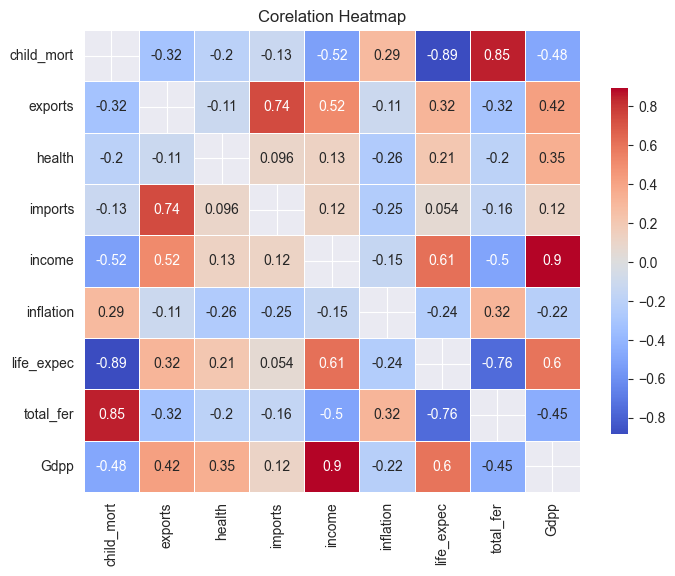

In [10]:
corr = df.corr()

np.fill_diagonal(corr.values, np.nan)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'shrink':0.75
    }
)
plt.title('Corelation Heatmap')
plt.show



# The relationship between income and gdpp was found to have the highest correlation. 

In [11]:
#VIF (Variance Inflation Factor)

X = df.drop(columns=['Gdpp'])
y = df['Gdpp']

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13


In [12]:
y[0:5]

0      553
1     4090
2     4460
3     3530
4    12200
Name: Gdpp, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((133, 8), (34, 8), (133,), (34,))

In [15]:
#  Scaler to data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-0.83746628, -0.46960119,  1.02705834, ..., -0.59499747,
         1.1087671 , -0.70605991],
       [-0.29757844, -0.03846097, -0.99004398, ...,  0.67078917,
         0.68784703, -0.08237768],
       [-0.598059  ,  0.50257773, -0.31521816, ..., -0.63332824,
         0.34446486, -0.93109988],
       ...,
       [-0.83013748,  0.51103146, -0.4590335 , ...,  0.58367378,
         0.01215954, -0.98253759],
       [-0.71043384,  0.02071513,  0.08672728, ..., -0.55405324,
         0.41092593, -0.99539702],
       [-0.54431451, -0.00464606,  1.78669834, ...,  0.23521221,
        -0.06537837, -1.12399129]], shape=(133, 8))

# çoklu corelasyona bakıldı 
# ols = sıkıntıyı tespit edebilir model için hangi feature ları kullanmalıyım. modelin performansı ne (tahimn + istatistiksel datalar karar verede yardımcı)
# sklearn = tahmini söyler 

In [16]:
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [17]:
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gdpp   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     101.3
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.19e-50
Time:                        16:36:46   Log-Likelihood:                -1365.3
No. Observations:                 133   AIC:                             2749.
Df Residuals:                     124   BIC:                             2775.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.321e+04    624.340     21.154      0.0

In [18]:
y_pred = ols.predict(X_test_sm)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_absolute_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(
    f'Test R2: {r2:.4f}\n'
    f'Test RMSE: {rmse:.2f}\n'
    f'Test MAE: {mae:2f}'
)

Test R2: 0.8268
Test RMSE: 68.49
Test MAE: 4690.960179


<function matplotlib.pyplot.show(close=None, block=None)>

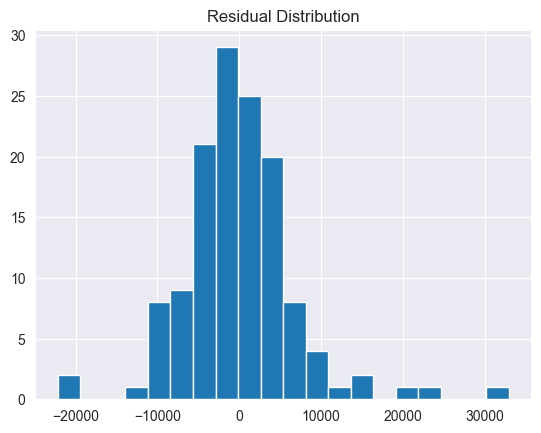

In [20]:
resid = y_train - ols.predict(X_train_sm)

plt.hist(resid, bins=20)
plt.title('Residual Distribution')
plt.show

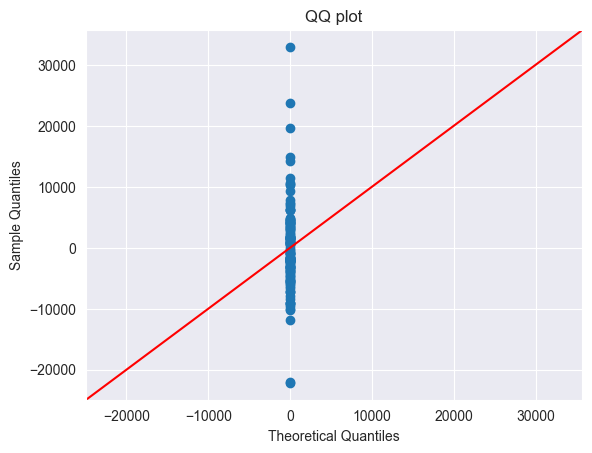

In [21]:
sm.qqplot(resid, line='45')
plt.title('QQ plot')
plt.show()

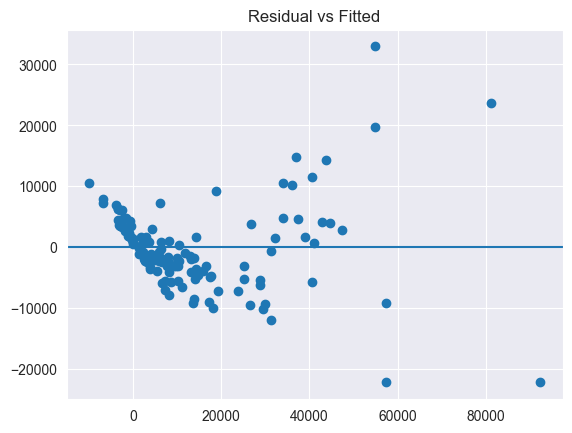

In [22]:
plt.scatter(ols.predict(X_train_sm), resid)

plt.axhline(0)
plt.title('Residual vs Fitted')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='euclidean',
    p=2
)

: 

In [19]:
# # Create a Feature DataSet
# X_features = df.drop(columns=['Gdpp'])




# X_scaled = scaler.fit_transform(X)
# X_scaled = sm.add_constant(X_scaled)



# # Table of VIF 

# vif_data = pd.DataFrame()

# vif_data['feature'] = ['const'] + list(X.columns)
# vif_data['VIF Score'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
# vif_data.sort_values(by='VIF Score', ascending=False)